<a href="https://colab.research.google.com/github/joserosania123/panama-electricity-forecaster/blob/main/Panama_Electricity_Demand_Forecaster.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

print("All libraries loaded successfully!")

All libraries loaded successfully!


In [19]:
# Load the data
df = pd.read_csv('/content/owid-energy-data.csv')

# First look
print("Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nColumns:")
print(df.columns.tolist())

Shape: (23195, 130)

First 5 rows:
         country  year iso_code  population  gdp  biofuel_cons_change_pct  \
0  ASEAN (Ember)  2000      NaN         NaN  NaN                      NaN   
1  ASEAN (Ember)  2001      NaN         NaN  NaN                      NaN   
2  ASEAN (Ember)  2002      NaN         NaN  NaN                      NaN   
3  ASEAN (Ember)  2003      NaN         NaN  NaN                      NaN   
4  ASEAN (Ember)  2004      NaN         NaN  NaN                      NaN   

   biofuel_cons_change_twh  biofuel_cons_per_capita  biofuel_consumption  \
0                      NaN                      NaN                  NaN   
1                      NaN                      NaN                  NaN   
2                      NaN                      NaN                  NaN   
3                      NaN                      NaN                  NaN   
4                      NaN                      NaN                  NaN   

   biofuel_elec_per_capita  ...  solar_share_

In [20]:
# Filter for Panama only
panama = df[df['country'] == 'Panama'].copy()

print("Panama data shape:", panama.shape)
print("\nYears available:", panama['year'].min(), "to", panama['year'].max())
print("\nPanama columns with data:")
print(panama.notna().sum()[panama.notna().sum() > 0])

Panama data shape: (44, 130)

Years available: 1980 to 2023

Panama columns with data:
country                 44
year                    44
iso_code                44
population              44
gdp                     43
                        ..
solar_electricity       24
solar_share_elec        24
wind_elec_per_capita    24
wind_electricity        24
wind_share_elec         24
Length: 66, dtype: int64


In [21]:
# Select key columns for Panama
panama_clean = panama[[
    'year',
    'population',
    'gdp',
    'electricity_demand',
    'electricity_generation',
    'electricity_share_energy',
    'fossil_electricity',
    'renewables_electricity',
    'solar_electricity',
    'wind_electricity',
    'hydro_electricity'
]].copy()

print(panama_clean)
print("\nMissing values per column:")
print(panama_clean.isnull().sum())

       year  population           gdp  electricity_demand  \
16812  1980   1957496.0  1.342404e+10                 NaN   
16813  1981   2004379.0  1.461869e+10                 NaN   
16814  1982   2052231.0  1.518576e+10                 NaN   
16815  1983   2101067.0  1.495407e+10                 NaN   
16816  1984   2150738.0  1.526862e+10                 NaN   
16817  1985   2200878.0  1.605187e+10                 NaN   
16818  1986   2251272.0  1.676254e+10                 NaN   
16819  1987   2301926.0  1.727282e+10                 NaN   
16820  1988   2352806.0  1.552239e+10                 NaN   
16821  1989   2403760.0  1.576011e+10                 NaN   
16822  1990   2455535.0  1.703577e+10                 NaN   
16823  1991   2508220.0  1.869677e+10                 NaN   
16824  1992   2561294.0  2.028194e+10                 NaN   
16825  1993   2615043.0  2.144780e+10                 NaN   
16826  1994   2669500.0  2.212649e+10                 NaN   
16827  1995   2724493.0 

In [22]:
# Keep only rows where electricity_demand exists
panama_clean = panama_clean.dropna(subset=['electricity_demand'])

# Fill remaining missing values with 0 for solar/wind
panama_clean['solar_electricity'] = panama_clean['solar_electricity'].fillna(0)
panama_clean['wind_electricity'] = panama_clean['wind_electricity'].fillna(0)
panama_clean['renewables_electricity'] = panama_clean['renewables_electricity'].fillna(0)
panama_clean['fossil_electricity'] = panama_clean['fossil_electricity'].fillna(0)
panama_clean['hydro_electricity'] = panama_clean['hydro_electricity'].fillna(0)

# Fill gdp with forward fill
panama_clean['gdp'] = panama_clean['gdp'].ffill()

# Reset index
panama_clean = panama_clean.reset_index(drop=True)

print("Clean data shape:", panama_clean.shape)
print("\nMissing values remaining:")
print(panama_clean.isnull().sum())
print("\nYears in clean data:", panama_clean['year'].tolist())

Clean data shape: (24, 11)

Missing values remaining:
year                         0
population                   0
gdp                          0
electricity_demand           0
electricity_generation       0
electricity_share_energy    24
fossil_electricity           0
renewables_electricity       0
solar_electricity            0
wind_electricity             0
hydro_electricity            0
dtype: int64

Years in clean data: [2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023]


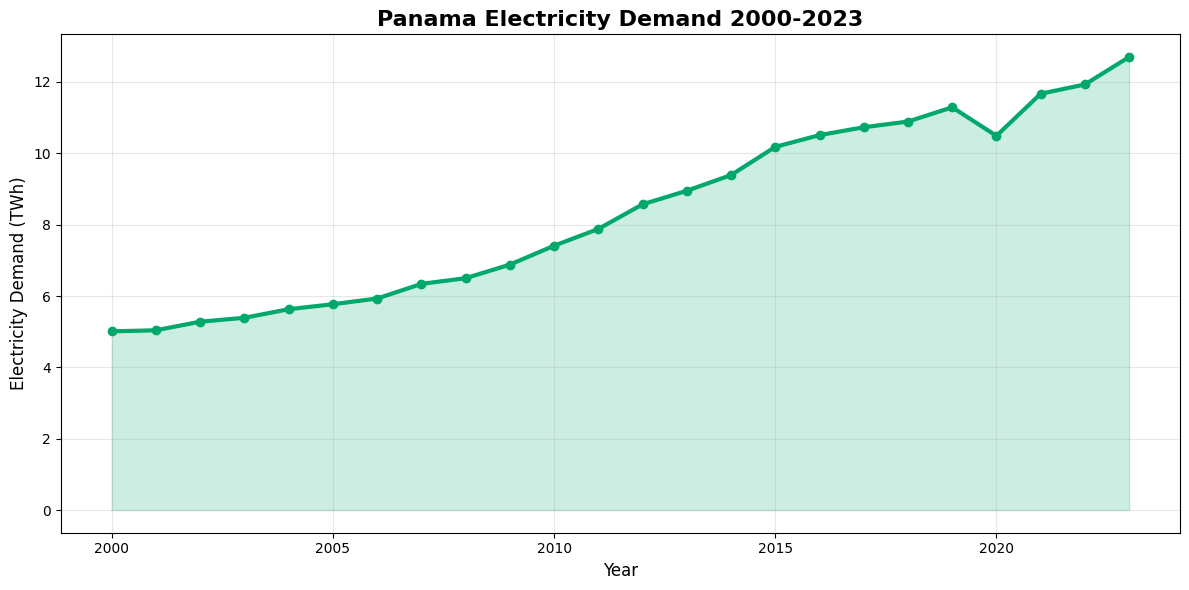

Chart 1 saved!


In [23]:
# VISUALIZATION 1 - Panama Electricity Demand Over Time
plt.figure(figsize=(12, 6))
plt.plot(panama_clean['year'], panama_clean['electricity_demand'],
         color='#00A86B', linewidth=3, marker='o', markersize=6)
plt.fill_between(panama_clean['year'], panama_clean['electricity_demand'],
                 alpha=0.2, color='#00A86B')
plt.title('Panama Electricity Demand 2000-2023', fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Electricity Demand (TWh)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('panama_demand_over_time.png', dpi=150)
plt.show()
print("Chart 1 saved!")

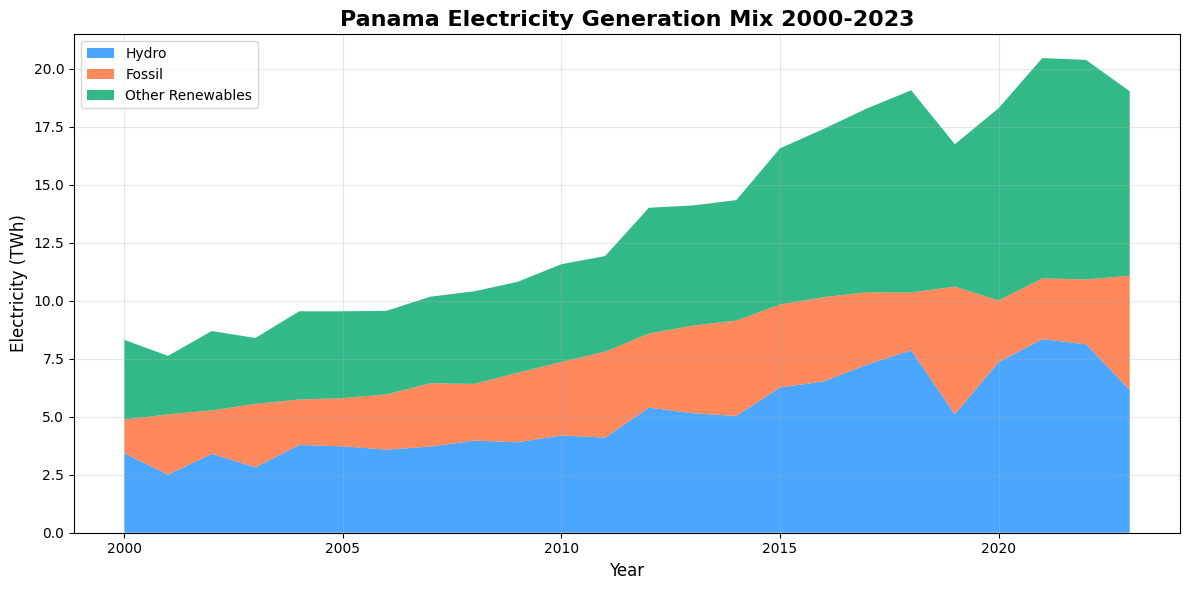

Chart 2 saved!


In [24]:
# VISUALIZATION 2 - Panama Energy Mix Over Time
plt.figure(figsize=(12, 6))
plt.stackplot(panama_clean['year'],
              panama_clean['hydro_electricity'],
              panama_clean['fossil_electricity'],
              panama_clean['renewables_electricity'],
              labels=['Hydro', 'Fossil', 'Other Renewables'],
              colors=['#1E90FF', '#FF6B35', '#00A86B'],
              alpha=0.8)
plt.title('Panama Electricity Generation Mix 2000-2023', fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Electricity (TWh)', fontsize=12)
plt.legend(loc='upper left', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('panama_energy_mix.png', dpi=150)
plt.show()
print("Chart 2 saved!")

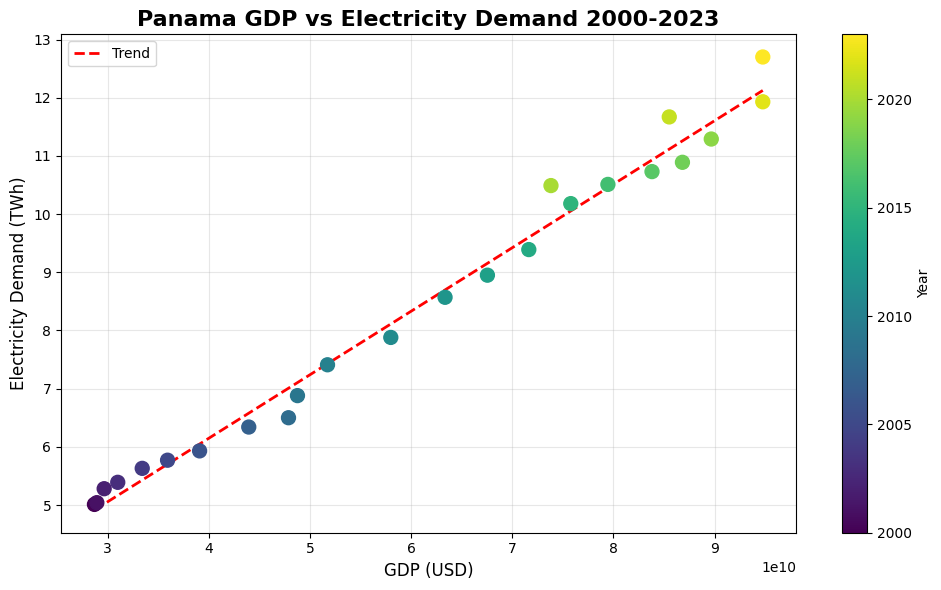

Chart 3 saved!


In [25]:
# VISUALIZATION 3 - GDP vs Electricity Demand
plt.figure(figsize=(10, 6))
plt.scatter(panama_clean['gdp'], panama_clean['electricity_demand'],
            c=panama_clean['year'], cmap='viridis', s=100, zorder=5)
plt.colorbar(label='Year')

# Add trend line
z = np.polyfit(panama_clean['gdp'], panama_clean['electricity_demand'], 1)
p = np.poly1d(z)
gdp_range = np.linspace(panama_clean['gdp'].min(), panama_clean['gdp'].max(), 100)
plt.plot(gdp_range, p(gdp_range), 'r--', linewidth=2, label='Trend')

plt.title('Panama GDP vs Electricity Demand 2000-2023', fontsize=16, fontweight='bold')
plt.xlabel('GDP (USD)', fontsize=12)
plt.ylabel('Electricity Demand (TWh)', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('panama_gdp_vs_demand.png', dpi=150)
plt.show()
print("Chart 3 saved!")

In [26]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np

# Define features and target
features = ['year', 'population', 'gdp',
            'electricity_generation', 'fossil_electricity',
            'renewables_electricity', 'hydro_electricity']

target = 'electricity_demand'

X = panama_clean[features]
y = panama_clean[target]

# Leave One Out cross validation
loo = LeaveOneOut()
predictions = []
actuals = []

model = RandomForestRegressor(n_estimators=100, random_state=42)

for train_idx, test_idx in loo.split(X):
    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]
    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    predictions.append(pred[0])
    actuals.append(y_test.values[0])

mae = mean_absolute_error(actuals, predictions)
r2 = r2_score(actuals, predictions)
mape = np.mean(np.abs((np.array(actuals) - np.array(predictions)) / np.array(actuals))) * 100

print("MODEL RESULTS")
print("=" * 40)
print("R2 Score:              ", round(r2, 4))
print("Mean Absolute Error:   ", round(mae, 2), "TWh")
print("Mean Absolute % Error: ", round(mape, 2), "%")
print("Accuracy:              ", round(100 - mape, 2), "%")
print("=" * 40)

MODEL RESULTS
R2 Score:               0.9784
Mean Absolute Error:    0.23 TWh
Mean Absolute % Error:  2.57 %
Accuracy:               97.43 %


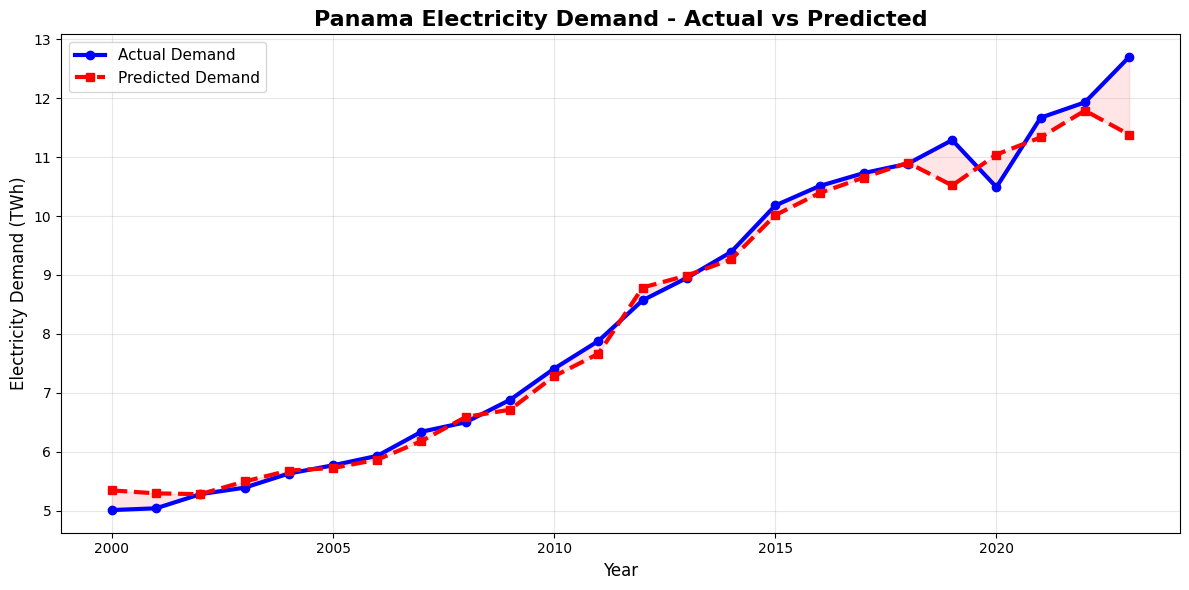

Final chart saved!
Project complete!


In [27]:
# VISUALIZATION 4 - Actual vs Predicted
plt.figure(figsize=(12, 6))
plt.plot(panama_clean['year'], actuals,
         color='blue', linewidth=3, marker='o',
         markersize=6, label='Actual Demand')
plt.plot(panama_clean['year'], predictions,
         color='red', linewidth=3, marker='s',
         markersize=6, linestyle='--', label='Predicted Demand')
plt.fill_between(panama_clean['year'], actuals, predictions,
                 alpha=0.1, color='red')
plt.title('Panama Electricity Demand - Actual vs Predicted',
          fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Electricity Demand (TWh)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=150)
plt.show()
print("Final chart saved!")
print("Project complete!")

# Panama Electricity Demand Forecaster

## About This Project
Using World Energy Consumption data to analyze and predict
Panama's electricity demand using Machine Learning.

## Data Source
World Energy Consumption Dataset - Kaggle